<a href="https://colab.research.google.com/github/anaguilarar/WeatherSoilDataProcessor/blob/main/google_colab_examples/banana_n_spatial_crop_simulation_pixel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook demonstrates how to perform a spatial crop simulation at a pixel-scale resolution using the WeatherSoilDataProcessor library and the DSSAT model. It covers downloading necessary spatial data (weather and soil), creating data cubes, and running the crop model simulation.

In [1]:
!git clone https://github.com/anaguilarar/WeatherSoilDataProcessor.git

import os
os.chdir('/content/WeatherSoilDataProcessor')

!pip install -r /content/WeatherSoilDataProcessor/requirements.txt

Cloning into 'WeatherSoilDataProcessor'...
remote: Enumerating objects: 2607, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (199/199), done.
remote: Total 2607 (delta 168), reused 150 (delta 68), pack-reused 2336 (from 1)
Receiving objects: 100% (2607/2607), 126.80 MiB | 19.69 MiB/s, done.
Resolving deltas: 100% (2066/2066), done.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of rioxarray to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
!pip install hvplot panel param geoviews bokeh jupyter_bokeh -U
from google.colab import output
output.enable_custom_widget_manager()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: bokeh
    Found existing installation: bokeh 3.8.2
    Uninstalling bokeh-3.8.2:
      Successfully uninstalled bokeh-3.8.2
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninst

# Run Spatial Crop Simulation at Pixel-Scale Resolution

This example demonstrates how to simulate the potential yield of a specific crop at a fine spatial resolution (250m), aligning with the SoilGrids project resolution. The simulation requires detailed information on soil and weather conditions, as well as specified management practices.

## Repository Structure

The repository is organized into three main components:

1. [**Crop Modeling Using Banana_n Model:**](#cropmodel)
   - Configuration file setup
   - Running Banana_n
   - Plotting the results

## 1. Crop Modeling Using the Banana_n Model<a id="cropmodel"></a>




### Spatial Data

In [9]:
import os
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


input_fileid = '1Yf0-kqod874ysAxWkyiBk-41EwOR0AfG'

if not os.path.exists(input_folder + '.zip'):
  !gdown --id {input_fileid} --output {input_folder + '.zip'}



/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Yf0-kqod874ysAxWkyiBk-41EwOR0AfG
To: /content/WeatherSoilDataProcessor/bananan_guadalupe.zip
100% 19.9M/19.9M [00:00<00:00, 198MB/s]


In [4]:
!rm -rf /content/bananan_guadalupe


In [5]:
import zipfile
from pathlib import Path

# Use Pathlib for robust path handling
zip_path = Path("/content/bananan_guadalupe.zip")
extract_to = Path("/content/")

# Create the directory if it doesn't exist
extract_to.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
    print(f"Successfully unzipped to: {extract_to}")

Successfully unzipped to: /content


### Configuration file setup

To specify that the analysis will be done at pixel-scale, we set 'pixel' in the configuration dictionary.

Other parameters to configure include crop parameters and management practices.
Below is an example of how to define these parameters. For more examples, please check the options/dssat_options folder.

In [12]:
import os
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

os.chdir('/content/WeatherSoilDataProcessor')
from crop_modeling.spatial_process import SpatialCM
import numpy as np
import pandas as pd
import geopandas as gpd

input_folder = '/content/bananan_guadalupe'
climate_path = '/content/bananan_guadalupe/weather_guadalupe_2021_2023.nc'
soil_path = '/content/bananan_guadalupe/soilgrids_guad.nc'
dem_path = '/content/bananan_guadalupe/guadalupe_dem.tif'
vector_path = '/content/bananan_guadalupe/guadalupe_whole.shp'
cm_configuration = {
    'GENERAL_INFO': {
        'country': 'Guadalupe',
        'country_code': 'GUAD', # crountry code
        'working_path': 'runs', # the model outputs will be located in this path
        'ncores': 5,
        'model': 'banana_n',
        'bin_path': None
    },
    'SPATIAL_INFO':{
        'geospatial_path': vector_path, # spatial file that contains the region of interest
        'feature_name': 'id', ## an unique code that represent each region of interest
        'adm_level': 2,
        'aggregate_by' : 'pixel',
        'soil_path' : soil_path,
        'weather_path': climate_path,
        'dem_path': dem_path,
        'scale_factor': 1 # scale factor for soil and weather spatial resolution combination. the scale resample is applied to the climate datacube 5 times represents ~1km
    },
    'CROP':{
        'name': 'Banana',
        'cultivar': None,

    },
    'MANAGEMENT':{
        'planting_date': '2021-05-01',
        'plantingWindow': 20,
        'nweeks_cycle': 81
    }
}



### Running BANANA N

In [13]:
# Initialize the spatial crop modeling class
cm_sp = SpatialCM(configuration_dict=cm_configuration)

feat_attr = cm_configuration['SPATIAL_INFO'].get('feature_name', None)
geocode = 97110
roi = cm_sp.geo_features.loc[cm_sp.geo_features[feat_attr]==str(geocode)]
roi_name = roi[cm_sp.config.SPATIAL_INFO.feature_name].values[0]
roi
cm_sp.set_up_folders(site = roi_name)

loaded from /content/bananan_guadalupe/soilgrids_guad.nc
loaded from /content/bananan_guadalupe/weather_guadalupe_2021_2023.nc
loaded from /content/bananan_guadalupe/guadalupe_dem.tif


<Axes: >

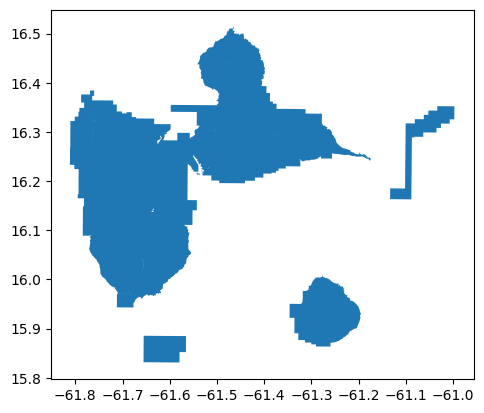

In [14]:
roi.plot()

In [ ]:

import shutil
if os.path.exists(f'/content/WeatherSoilDataProcessor/runs/{geocode}'):
  shutil.rmtree(f'/content/WeatherSoilDataProcessor/runs/{geocode}', ignore_errors=False, onerror=None)

In [22]:
workingpath = cm_sp.create_roi_sp_data(
     roi= roi,
     export_spatial_data= True
 )


if workingpath is not None:
    # Locate environmental working paths
    cm_sp.model.find_envworking_paths(cm_sp._tmp_path, 'csv')
    cm_sp.model._enviroments = {}
    # Set up crop files
    nbweeks = cm_configuration['MANAGEMENT']['nweeks_cycle']
    planting_date = cm_configuration['MANAGEMENT']['planting_date']
    cm_sp.model.set_up_crop(starting_date= planting_date, time_step_weeks=2, cycle_duration_weeks = nbweeks)
    cm_sp.model.organize_enviromental_data()

    # run the simulation
    completed_sims = cm_sp.model.run()

    print(completed_sims)
else:
    print('there is no information')

  4%|▎         | 2/54 [00:00<00:04, 10.81it/s]

Request for treatment 40 generated an exception: Reindexing only valid with uniquely valued Index objects
Request for treatment 24 generated an exception: Reindexing only valid with uniquely valued Index objects
Request for treatment 41 generated an exception: Reindexing only valid with uniquely valued Index objects


100%|██████████| 54/54 [00:03<00:00, 16.28it/s]


crop data set up for runs/97110/_157
crop data set up for runs/97110/_96
crop data set up for runs/97110/_92
crop data set up for runs/97110/_87
crop data set up for runs/97110/_76
crop data set up for runs/97110/_174
crop data set up for runs/97110/_226
crop data set up for runs/97110/_156
crop data set up for runs/97110/_90
crop data set up for runs/97110/_191
crop data set up for runs/97110/_141
crop data set up for runs/97110/_214
crop data set up for runs/97110/_198
crop data set up for runs/97110/_122
crop data set up for runs/97110/_110
crop data set up for runs/97110/_41
crop data set up for runs/97110/_123
crop data set up for runs/97110/_190
crop data set up for runs/97110/_109
crop data set up for runs/97110/_40
crop data set up for runs/97110/_24
crop data set up for runs/97110/_121
crop data set up for runs/97110/_88
crop data set up for runs/97110/_173
crop data set up for runs/97110/_94
crop data set up for runs/97110/_75
crop data set up for runs/97110/_232
crop data se

100%|██████████| 54/54 [11:56<00:00, 13.27s/it]

{'runs/97110/_157': True, 'runs/97110/_96': True, 'runs/97110/_92': True, 'runs/97110/_87': True, 'runs/97110/_76': True, 'runs/97110/_174': True, 'runs/97110/_226': True, 'runs/97110/_156': True, 'runs/97110/_90': True, 'runs/97110/_191': True, 'runs/97110/_141': True, 'runs/97110/_214': True, 'runs/97110/_198': True, 'runs/97110/_122': True, 'runs/97110/_110': True, 'runs/97110/_41': True, 'runs/97110/_123': True, 'runs/97110/_190': True, 'runs/97110/_109': True, 'runs/97110/_24': True, 'runs/97110/_121': True, 'runs/97110/_88': True, 'runs/97110/_173': True, 'runs/97110/_94': True, 'runs/97110/_75': True, 'runs/97110/_232': True, 'runs/97110/_58': True, 'runs/97110/_105': True, 'runs/97110/_77': True, 'runs/97110/_69': True, 'runs/97110/_140': True, 'runs/97110/_104': True, 'runs/97110/_155': True, 'runs/97110/_89': True, 'runs/97110/_216': True, 'runs/97110/_139': True, 'runs/97110/_59': True, 'runs/97110/_91': True, 'runs/97110/_42': True, 'runs/97110/_138': True, 'runs/97110/_86'

### Crop simulation outputs

After completing the simulation, the next step is to generate the output maps.


In [23]:

from crop_modeling.banana_n.output import update_banana_n_data_using_path
from crop_modeling.spatial_process import create_mlt_yield_raster
from crop_modeling.utils.output_transforms import summarize_spatial_yields_by_time_window
import rioxarray as rio
import matplotlib.pyplot as plt
import os



refraster = rio.open_rasterio(os.path.join(cm_sp._tmp_path,'ref_raster.tif'))
model_data = update_banana_n_data_using_path(cm_sp._tmp_path)

mlt_pot_yield = create_mlt_yield_raster(refraster, model_data, date_column = 'sowing_date', ycol_name ='fruit_yield', select_highest_value = True )
### Summarizing data by planting window


100%|██████████| 59/59 [00:00<00:00, 143.98it/s]


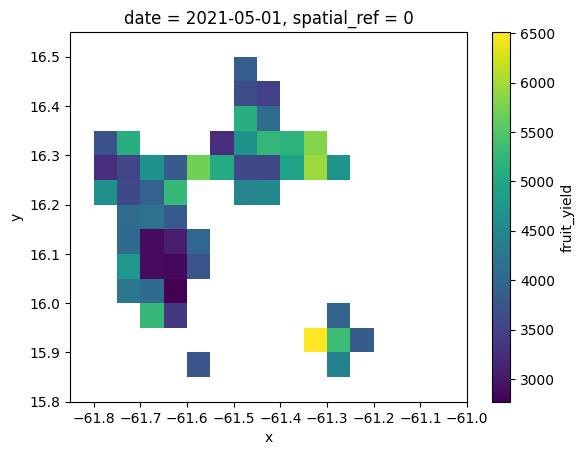

In [25]:
mlt_pot_yield.isel(date= 0).fruit_yield.plot()

### Paper comparison

In order to evaluate the accuracy of the Python implementation, four distinct comparisons were performed:
1. Python implementation using the conditions reported in the paper: climate data (weather station) and soil data (field measurements).
2. Python implementation using weather station data combined with SoilGrids data.
3. Python implementation using climate data derived from AgERA5 and CHIRPS (large-scale data) combined with field measurements.
4. Finally, Python implementation using climate data derived from AgERA5 and CHIRPS (large-scale data) combined with SoilGrids data.



1. Python implementation using the conditions reported in the paper:

<Axes: xlabel='Week'>

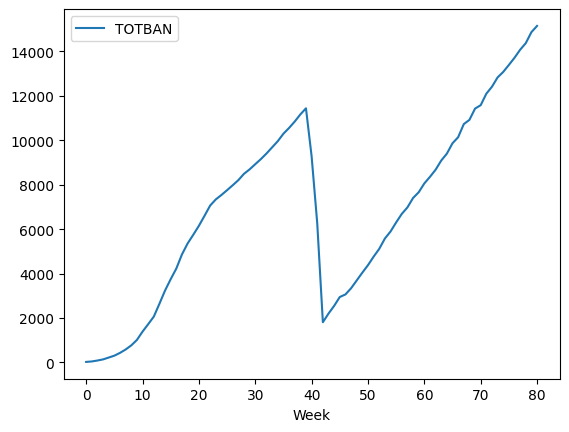

In [27]:
from crop_modeling.banana_n.base import BANANAField, soil_initial_conditions, banana_cycle_weekly_weather
from datetime import datetime, timedelta



ferti_mock = [{'application': False, 'q_org': 0.0, 'min_f': 0.0} for _ in range(nbweeks)]
papersweather = pd.read_csv("/content/bananan_guadalupe/weather_80_weeks.csv")
papersweather = papersweather.to_dict(orient='records')

paper_soil_values = {'wsol1': 184.8,
 'wsol2': 197.4,
 'son': 9923.077,
 'smn_depth1': 70.96154,
 'smn_depth2': 50.44038}

densite = 1300
nban = 40

modelsoilpaper = BANANAField(nban=nban, density= densite, init_soil_parameters=paper_soil_values)
bananacycle = modelsoilpaper.simulate(nb_weeks = nbweeks, weather_data = papersweather, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')

In [29]:
cm_sp.model._enviroments

{'runs/97110/_157': {'planting_date': '2021-05-01',
  'time_step_weeks': 2,
  'cycle_duration_weeks': 81,
  'soil': <crop_modeling.banana_n.soil.BanSoil at 0x7c877b07dcd0>,
  'weathert': <crop_modeling.banana_n.weather.BanWeather at 0x7c877ab0e210>,
  'reporter': <crop_modeling.banana_n.output.BananaNOutputData at 0x7c8781d13440>},
 'runs/97110/_96': {'planting_date': '2021-05-01',
  'time_step_weeks': 2,
  'cycle_duration_weeks': 81,
  'soil': <crop_modeling.banana_n.soil.BanSoil at 0x7c877b07f8c0>,
  'weathert': <crop_modeling.banana_n.weather.BanWeather at 0x7c877b07c3e0>,
  'reporter': <crop_modeling.banana_n.output.BananaNOutputData at 0x7c878269dc70>},
 'runs/97110/_92': {'planting_date': '2021-05-01',
  'time_step_weeks': 2,
  'cycle_duration_weeks': 81,
  'soil': <crop_modeling.banana_n.soil.BanSoil at 0x7c877b07df70>,
  'weathert': <crop_modeling.banana_n.weather.BanWeather at 0x7c877b07f6b0>,
  'reporter': <crop_modeling.banana_n.output.BananaNOutputData at 0x7c878623d430>},


2. Python implementation using weather station data combined with SoilGrids data.

<Axes: xlabel='Week'>

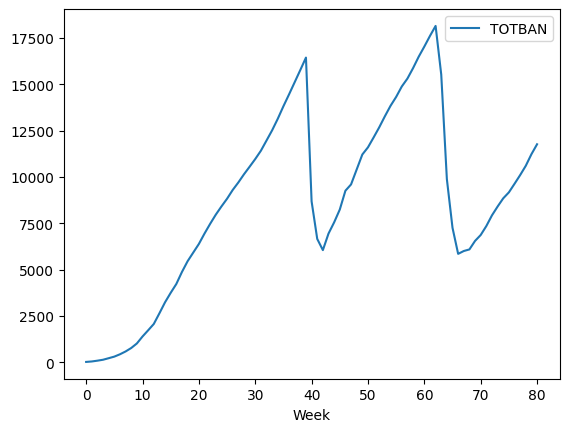

In [30]:
init_soil_parameters = soil_initial_conditions(cm_sp.model._enviroments['runs/97110/_106'])

papersweather = pd.read_csv("/content/bananan_guadalupe/weather_80_weeks.csv")
papersweather = papersweather.to_dict(orient='records')



model = BANANAField(nban=40, density= 1300, init_soil_parameters=init_soil_parameters)
bananacycle = model.simulate(nb_weeks = nbweeks, weather_data = papersweather, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')


3. Python implementation using climate data derived from AgERA5 and CHIRPS (large-scale data) combined with field measurements.

<Axes: xlabel='Week'>

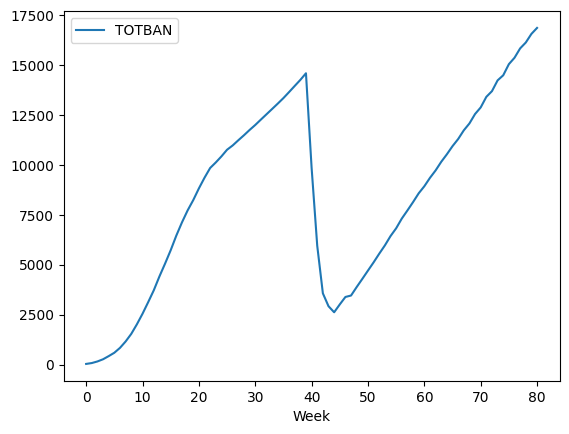

In [31]:

weather_weekly_data = banana_cycle_weekly_weather(cm_sp.model._enviroments['runs/97110/_106'], total_weeks=nbweeks)

paper_soil_values = {'wsol1': 184.8,
 'wsol2': 197.4,
 'son': 9923.077,
 'smn_depth1': 70.96154,
 'smn_depth2': 50.44038}

model = BANANAField(nban=40, density= 1300, init_soil_parameters=paper_soil_values)
bananacycle = model.simulate(nb_weeks = nbweeks, weather_data = weather_weekly_data, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')


4.  Python implementation using climate data derived from AgERA5 and CHIRPS combined with SoilGrids data.

<Axes: xlabel='Week'>

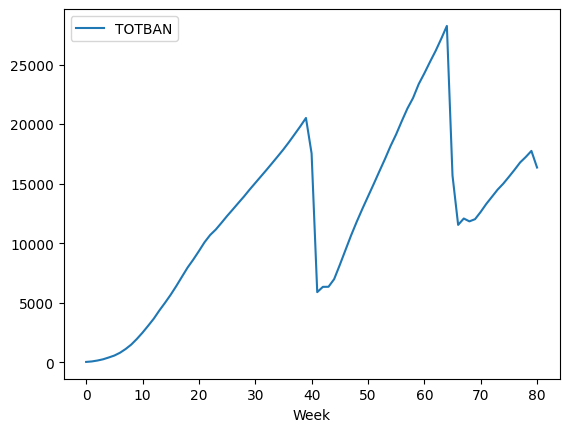

In [32]:
init_soil_parameters = soil_initial_conditions(cm_sp.model._enviroments['runs/97110/_106'])
weather_weekly_data = banana_cycle_weekly_weather(cm_sp.model._enviroments['runs/97110/_106'], total_weeks=nbweeks)

model = BANANAField(nban=40, density= 1300, init_soil_parameters=init_soil_parameters)
bananacycle = model.simulate(nb_weeks = nbweeks, weather_data = weather_weekly_data, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')

In [34]:
import hvplot.xarray
import holoviews as hv
import panel as pn

hv.extension("bokeh")
minlim = mlt_pot_yield.fruit_yield.min().values
maxlim = mlt_pot_yield.fruit_yield.max().values

mltmap = mlt_pot_yield.fruit_yield.hvplot.image(x='x', y='y', groupby = 'date',frame_height = 600, frame_width= 400, cmap='YlGnBu', fontscale=1.6, crs='EPSG:4326', tiles = 'EsriImagery', clim=(minlim,maxlim))

dmap_panel = pn.panel(mltmap)
dmap_panel


Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] WidgetBox(align=('end', 'start'))
        [0] Select(name='date', options=[np.str_('2021-05-01'), ...], value=np.str_('2021-05-01'))